In [ ]:
from model_ranking import (
    load_h5,
    get_random_colors,
    find_dataset_object_sizes,
)
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from pytorch3dunet.unet3d.utils import set_large_instances_to_zero

INFO: P [MainThread] 2025-10-09 17:58:14,711 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from model_ranking import (
    StandardEvalDataset,
    loader_classes,
    EvalDatasetConfig

)

eval_dataset_config = {
    "name": "StandardEvalDataset",
    "aug_name": "gauss_a005-01",
    "pred_path": ["/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/legacy_model/fw_model8/norm_50_950/gauss_a005-01/predictions"],
    "gt_path": ["/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/legacy_model/fw_model8/norm_50_950/none/predictions"],
    "pred_key": "segmentation",
    "gt_key": "segmentation",
    "patch_key": "patch_index",
    "roi": [[1436,1436]],
    "ignore_index": None,
    "ignore_path": "/scratch/talks/data/Ovules/GT2x/test/N_294_final_crop_ds2.h5",
    "ignore_key": "ignore_mask",
    "convert_to_binary_label": False,
    "convert_to_boundary_label": False,
    "gt_zero_large_instances": True,
    "gt_zero_largest_instance": False,
    "min_object_size": 1,
    "zero_large_instances": True,
    "zero_largest_instance": False,
    "largest_obj_multiplier": 1.5,
    "max_obj_size": 5867,
}

consis_cfg = EvalDatasetConfig.model_validate(eval_dataset_config)

dataset_class = loader_classes(consis_cfg.name)
consis_datasets = dataset_class.create_datasets(consis_cfg)

consis_dataset = consis_datasets[0]
print(len(consis_dataset))

5120


(1, 1, 256, 256) (1, 1, 256, 256)


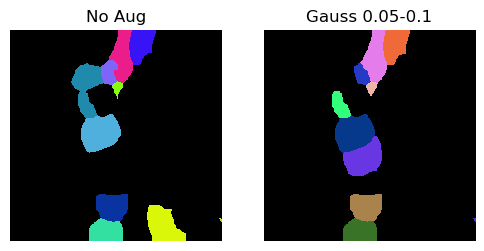

In [41]:
pred, no_aug_pred = consis_dataset[3421]
print(pred.shape, no_aug_pred.shape)
_, axs = plt.subplots(1, 2, figsize=(6, 3))
axs[0].imshow(no_aug_pred.squeeze(), cmap=get_random_colors(no_aug_pred), interpolation='nearest')
axs[0].set_title("No Aug")
axs[0].axis("off")
axs[1].imshow(pred.squeeze(), cmap=get_random_colors(pred), interpolation='nearest')
axs[1].set_title("Gauss 0.05-0.1")
axs[1].axis("off")
plt.show()


In [42]:
score, mask = adaRandError_eval(
    pred,
    no_aug_pred,
    incomplete_gt=False,
)
print(1 - score[0,0])
print(mask.shape)

0.7030560076236725
(1, 1, 256, 256)


In [64]:
from tqdm import trange, tqdm
from model_ranking import get_roi_slice

consis_scores = np.zeros((segs.shape[0], 3), dtype=np.float32)
for i in trange(segs.shape[0]):
#for i in tqdm([3421]):
    patch_roi = get_roi_slice(patch_indexes_new[i])
    ignore_mask_patch = ignore_mask[patch_roi]
    p_seg =  set_large_instances_to_zero(
        segs_new[i], threshold_multiplier=1.5, max_obj_size=5867
    ).squeeze()
    unp_seg = set_large_instances_to_zero(
        segs_NA_new[i], threshold_multiplier=1.5, max_obj_size=5867
    ).squeeze()
    
    # Apply ignore mask - set both segmentations to 0 where ignore_mask is True
    p_seg[ignore_mask_patch.squeeze() == 1] = 0
    unp_seg[ignore_mask_patch.squeeze() == 1] = 0

    # _, axs = plt.subplots(1, 2, figsize=(6, 3))
    # axs[0].imshow(unp_seg, cmap=get_random_colors(unp_seg), interpolation='nearest')
    # axs[0].set_title("No Aug")
    # axs[0].axis("off")
    # axs[1].imshow(p_seg, cmap=get_random_colors(p_seg), interpolation='nearest')
    # axs[1].set_title("Gauss 0.05-0.1")
    # axs[1].axis("off")
    # plt.show()

    score, _ = adaRandError_eval(
        p_seg,
        unp_seg,
        incomplete_gt=False,
    )
    #print(score)
    consis_scores[i] = score

100%|██████████| 5120/5120 [00:25<00:00, 203.21it/s]


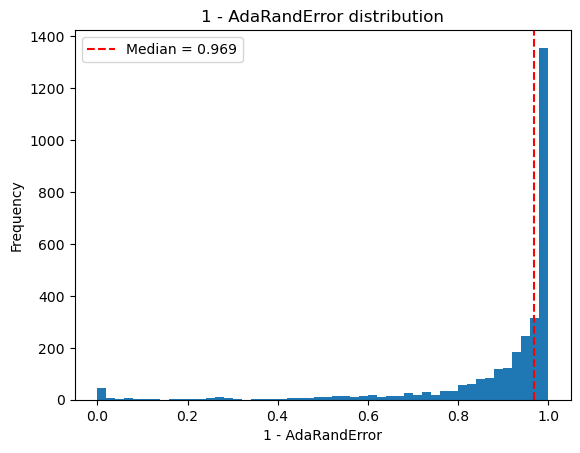

In [47]:
plt.hist(1 - consis_scores[:, 0], bins=50)
plt.axvline(x=(1-np.nanmedian(consis_scores[:, 0])), color='r', linestyle='--', label='Median = {:.3f}'.format(1-np.nanmedian(consis_scores[:, 0])))
plt.title("1 - AdaRandError distribution")
plt.xlabel("1 - AdaRandError")
plt.ylabel("Frequency")
plt.legend()
plt.show()

  0%|          | 0/1 [00:00<?, ?it/s]

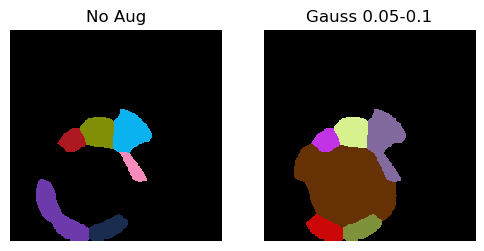

100%|██████████| 1/1 [00:00<00:00, 10.92it/s]

[[0.86860347 0.69139385 0.07259662]]


In [85]:
from tqdm import tqdm, trange
consis_scores2 = np.zeros((segs.shape[0], 3), dtype=np.float32)
#for i in trange(len(consis_dataset)):
for i in tqdm([1436]):
    pred, no_aug_pred = consis_dataset[i]
    _, axs = plt.subplots(1, 2, figsize=(6, 3))
    axs[0].imshow(no_aug_pred.squeeze(), cmap=get_random_colors(no_aug_pred), interpolation='nearest')
    axs[0].set_title("No Aug")
    axs[0].axis("off")
    axs[1].imshow(pred.squeeze(), cmap=get_random_colors(pred), interpolation='nearest')
    axs[1].set_title("Gauss 0.05-0.1")
    axs[1].axis("off")
    plt.show()
    score, _ = adaRandError_eval(
        pred,
        no_aug_pred,
        incomplete_gt=False,
    )
    print(score)
    consis_scores2[i] = score

In [51]:
nan_ids = np.where(np.isnan(consis_scores[:, 0]))[0]
print(len(nan_ids))

2077


In [52]:
nan_ids = np.where(np.isnan(consis_scores2[:, 0]))[0]
print(len(nan_ids))

2077


In [73]:
path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/legacy_model/fw_model8/norm_50_950/gauss_a005-01/predictions/N_294_final_crop_ds2_predictions.h5"
AdaRand_consis = load_h5(path, "AdaRandError_consis2")

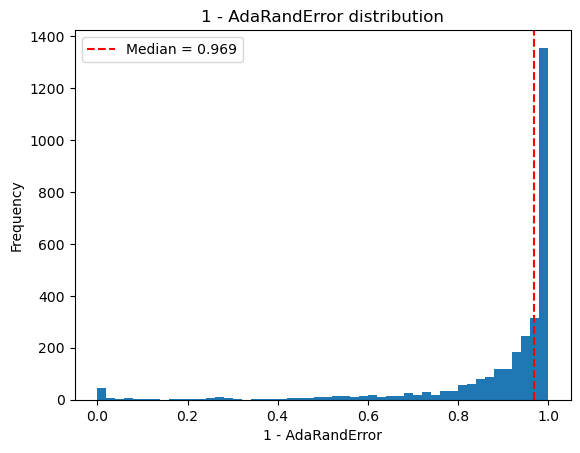

In [75]:
plt.hist(1 -AdaRand_consis[:, 0], bins=50)
plt.axvline(x=(1-np.nanmedian(AdaRand_consis[:, 0])), color='r', linestyle='--', label='Median = {:.3f}'.format(1-np.nanmedian(AdaRand_consis[:, 0])))
plt.title("1 - AdaRandError distribution")
plt.xlabel("1 - AdaRandError")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [79]:
# Check if all values are either equal (within tolerance) or both NaN
all_match = np.all(
    np.isclose(AdaRand_consis, consis_scores2, atol=1e-3, equal_nan=True)
)
print(f"All values match (equal or both NaN): {all_match}")

# Alternative check using logical conditions
element_wise_match = (
    np.isclose(AdaRand_consis, consis_scores2, atol=1e-5) | 
    (np.isnan(AdaRand_consis) & np.isnan(consis_scores2))
)
all_elements_match = np.all(element_wise_match)
print(f"All elements match (alternative check): {all_elements_match}")

# Find indices where they differ
diff_mask = ~np.isclose(AdaRand_consis[:, 0], consis_scores2[:, 0], atol=1e-5, equal_nan=True)
diff_indices = np.where(diff_mask)[0]

if len(diff_indices) > 0:
    print(f"Found {len(diff_indices)} differences at indices:")
    print(f"First 10 differing indices: {diff_indices[:10]}")
    print(f"AdaRand_consis values: {AdaRand_consis[diff_indices[:10], 0]}")
    print(f"consis_scores2 values: {consis_scores2[diff_indices[:10], 0]}")
else:
    print("No differences found between the arrays")

All values match (equal or both NaN): False
All elements match (alternative check): False
Found 4 differences at indices:
First 10 differing indices: [1340 1436 3326 4325]
AdaRand_consis values: [0.1287486  0.0249224  0.5845987  0.29913807]
consis_scores2 values: [0.91230756 0.86860347 0.01326774 0.09421039]


In [80]:
consis_scores2[1340]

array([0.91230756, 0.04585687, 1.        ], dtype=float32)

In [81]:
AdaRand_consis[1340]

array([0.1287486 , 0.8965358 , 0.84735405], dtype=float32)

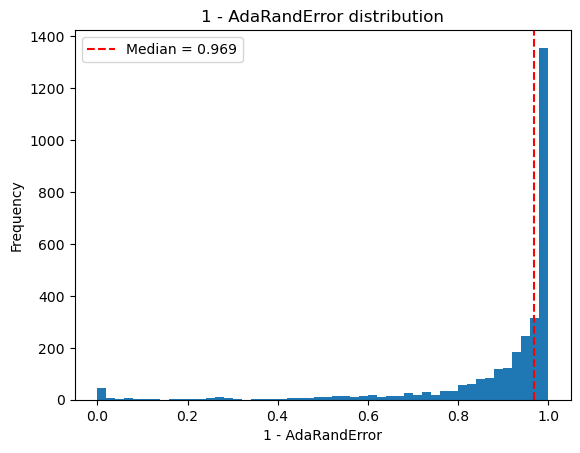

In [63]:
plt.hist(1 - consis_scores2[:, 0], bins=50)
plt.axvline(x=(1-np.nanmedian(consis_scores2[:, 0])), color='r', linestyle='--', label='Median = {:.3f}'.format(1-np.nanmedian(consis_scores2[:, 0])))
plt.title("1 - AdaRandError distribution")
plt.xlabel("1 - AdaRandError")
plt.ylabel("Frequency")
plt.legend()
plt.show()

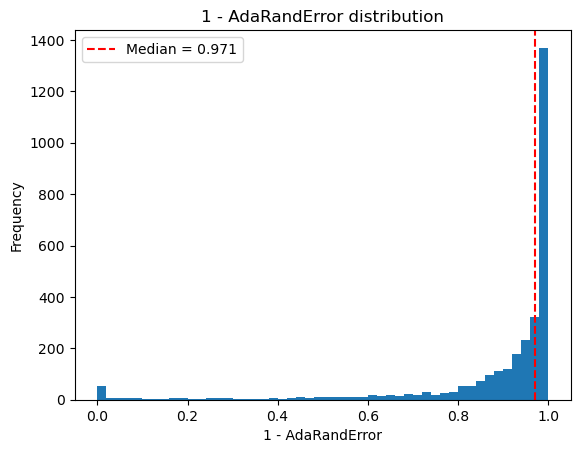

In [103]:
plt.hist(1 - consis_scores[non_nan_ids, 0], bins=50)
plt.axvline(x=(1-np.nanmedian(consis_scores[non_nan_ids, 0])), color='r', linestyle='--', label='Median = {:.3f}'.format(1-np.nanmedian(consis_scores[non_nan_ids, 0])))
plt.title("1 - AdaRandError distribution")
plt.xlabel("1 - AdaRandError")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [86]:
ids_1 = np.where((1 -consis_scores[:, 0] == 1))[0]
print(len(ids_1))

534


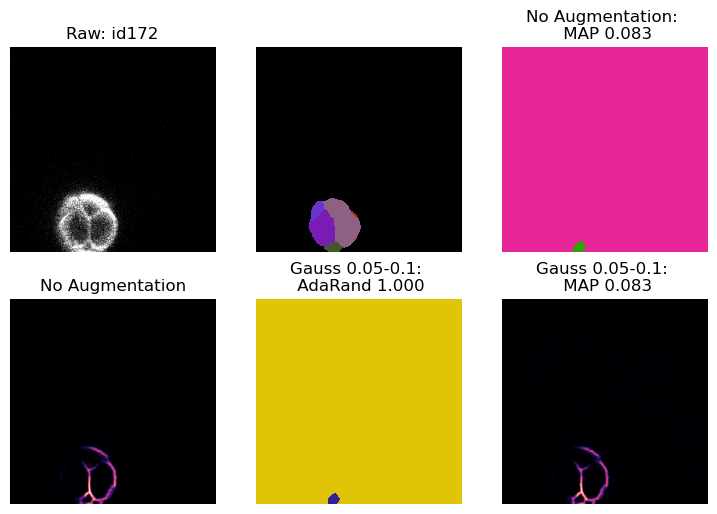

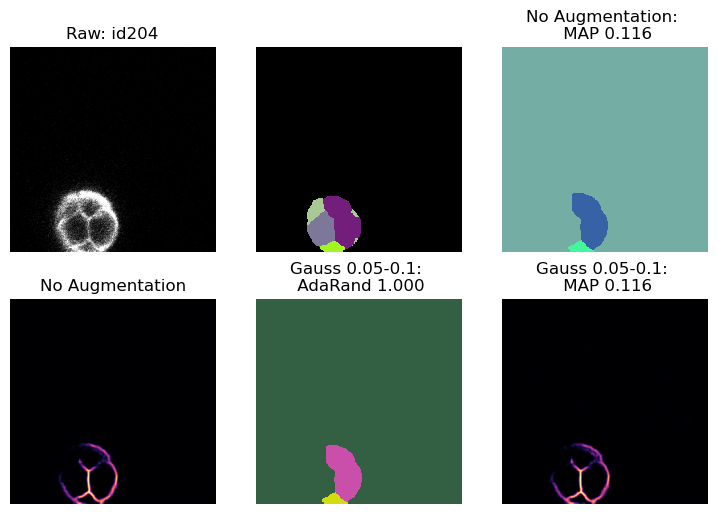

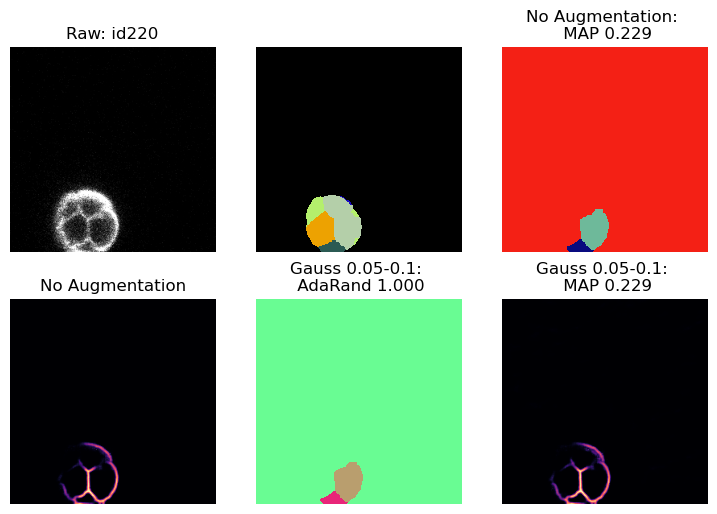

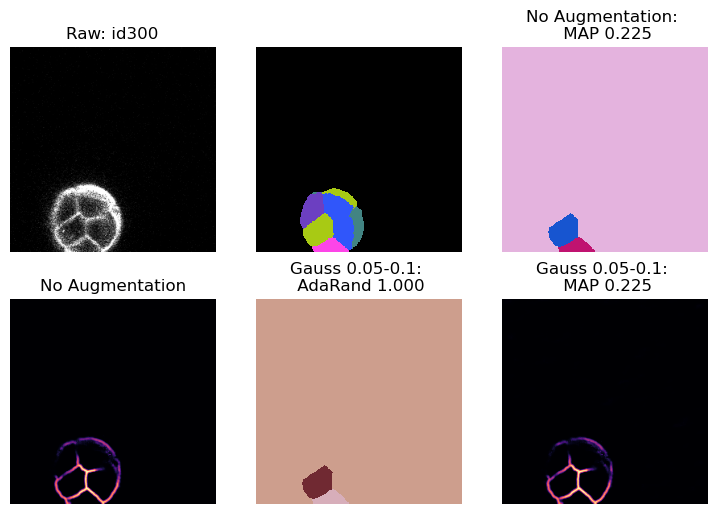

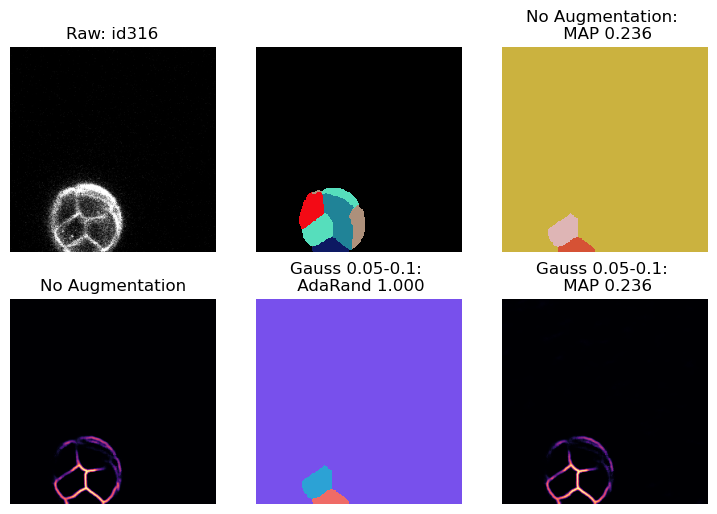

In [88]:
offset = 0
num_samples = 5
for i in ids_1[offset :offset + num_samples]:
    raw = load_h5(ov_raw_path, "raw", select_index=[i])
    gt = load_h5(ov_raw_path, "label", select_index=[i])
    _, axs = plt.subplots(2, 3, figsize=(9, 6))
    axs = axs.ravel()
    axs[0].imshow(raw.squeeze(), cmap="gray")
    axs[0].set_title(f"Raw: id{i}")
    axs[0].axis("off")
    axs[1].imshow(gt.squeeze(), cmap=get_random_colors(gt), interpolation='nearest')
    axs[1].axis("off")
    axs[2].imshow(segs_NA_new[i].squeeze(), cmap=get_random_colors(segs_new[i]), interpolation='nearest')
    axs[2].set_title("No Augmentation: \n MAP {:.3f}".format(MAP_score_NA_new[i]))
    axs[2].axis("off")
    axs[3].imshow(preds_NA_new[i].squeeze(), cmap="magma")
    axs[3].set_title("No Augmentation")
    axs[3].axis("off")
    axs[4].imshow(segs_new[i].squeeze(), cmap=get_random_colors(segs_new[i]), interpolation='nearest')
    axs[4].set_title("Gauss 0.05-0.1: \n AdaRand {:.3f}".format(1 - consis_scores[i, 0]))
    axs[4].axis("off")
    axs[5].imshow(preds_new[i].squeeze(), cmap="magma")
    axs[5].set_title("Gauss 0.05-0.1: \n MAP {:.3f}".format(MAP_score_new[i]))
    axs[5].axis("off")
    plt.show()